<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/01_Exploratory_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Exploratory Data Analysis

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Chapter 1 membahas tahapan pertama dan paling penting dalam proyek data science yaitu eksplorasi data. Fokus utamanya adalah bagaimana kita merangkum, memvisualisasikan, dan memahami karakteristik dasar dari sebuah dataset sebelum melangkah ke pemodelan statistik yang lebih rumit.

### Topik yang Dibahas:
1. Elemen Data Terstruktur
2. Estimasi Lokasi (Mean, Median, Robust Estimates)
3. Estimasi Variabilitas (Standard Deviation, MAD, IQR)
4. Eksplorasi Distribusi Data (Boxplot, Histogram, Density Plot)
5. Eksplorasi Data Biner dan Kategorikal
6. Korelasi
7. Eksplorasi Dua atau Lebih Variabel


***
## Setup: Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport.")


Library berhasil diimport.


***
## 1. Estimasi Lokasi

### Penjelasan Teori

Data biasanya memiliki ribuan nilai berbeda. Tahapan dasar dalam eksplorasi data adalah mendapatkan nilai representatif untuk setiap fitur. Nilai ini dikenal sebagai estimasi lokasi sentral.

* **Mean:** Rerata dari semua nilai. Sangat umum digunakan tetapi rentan terhadap outlier ekstrim.
* **Trimmed Mean:** Rerata setelah membuang persentase nilai ekstrim di ujung atas dan bawah. Lebih tangguh terhadap outlier.
* **Median:** Nilai tengah dari data yang telah diurutkan. Sangat tangguh terhadap outlier karena hanya melihat posisi tengah.
* **Weighted Mean:** Rerata berbobot, di mana setiap observasi dikalikan dengan bobot tertentu. Sangat berguna jika beberapa observasi memiliki kepentingan atau variabilitas yang berbeda.


In [ ]:
# Membuat dataset sintetis untuk mewakili negara bagian
state_data = {
    'State': ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware'],
    'Population': [4779736, 710231, 6392017, 2915918, 37253956, 5029196, 3574097, 897934],
    'MurderRate': [5.7, 5.6, 4.7, 5.6, 4.4, 2.8, 2.4, 5.8]
}
state = pd.DataFrame(state_data)

print("Tampilan awal dataset state:")
display(state.head())

mean_pop = state['Population'].mean()
trim_mean_pop = trim_mean(state['Population'], 0.1)
median_pop = state['Population'].median()

print(f"Mean Populasi: {mean_pop}")
print(f"Trimmed Mean Populasi: {trim_mean_pop}")
print(f"Median Populasi: {median_pop}")

weighted_mean = np.average(state['MurderRate'], weights=state['Population'])
print(f"Weighted Mean Murder Rate: {weighted_mean}")


Tampilan awal dataset state:


,State,Population,MurderRate
0,Alabama,4779736,5.7
1,Alaska,710231,5.6
2,Arizona,6392017,4.7
3,Arkansas,2915918,5.6
4,California,37253956,4.4


Mean Populasi: 7694135.625
Trimmed Mean Populasi: 7694135.625
Median Populasi: 4176916.5
Weighted Mean Murder Rate: 4.376359279149048


***
## 2. Estimasi Variabilitas

### Penjelasan Teori

Selain lokasi, kita juga perlu mengetahui variabilitas atau sebaran data. Apakah data mengelompok rapat atau menyebar luas?

* **Variance:** Rerata kuadrat selisih dari nilai mean.
* **Standard Deviation:** Akar kuadrat dari variance. Mudah diinterpretasikan karena memiliki satuan yang sama dengan data asli.
* **Median Absolute Deviation (MAD):** Median dari nilai absolut penyimpangan terhadap median. Ini adalah metrik yang kebal terhadap outlier.
* **Interquartile Range (IQR):** Selisih antara persentil ke tujuh puluh lima dan persentil ke dua puluh lima.


In [ ]:
std_pop = state['Population'].std()
iqr_pop = np.subtract(state['Population'].quantile(0.75), state['Population'].quantile(0.25))
mad_pop = np.median(np.abs(np.subtract(state['Population'], median_pop)))

print(f"Standard Deviation Populasi: {std_pop}")
print(f"IQR Populasi: {iqr_pop}")
print(f"MAD Populasi: {mad_pop}")


Standard Deviation Populasi: 12105745.29585633
IQR Populasi: 2958479.25
MAD Populasi: 1738049.5


***
## 3. Eksplorasi Distribusi Data

### Penjelasan Teori

Metrik di atas merangkum data menjadi satu angka pasti. Seringkali kita butuh melihat bagaimana data didistribusikan secara keseluruhan melalui visualisasi.

* **Boxplot:** Visualisasi berdasarkan persentil. Menampilkan rentang utama data dan nilai outlier.
* **Histogram:** Membagi rentang data ke dalam interval yang sama besar dan menghitung frekuensi nilai di setiap interval.
* **Density Plot:** Versi histogram yang lebih halus, dihitung menggunakan estimasi kepadatan kernel.


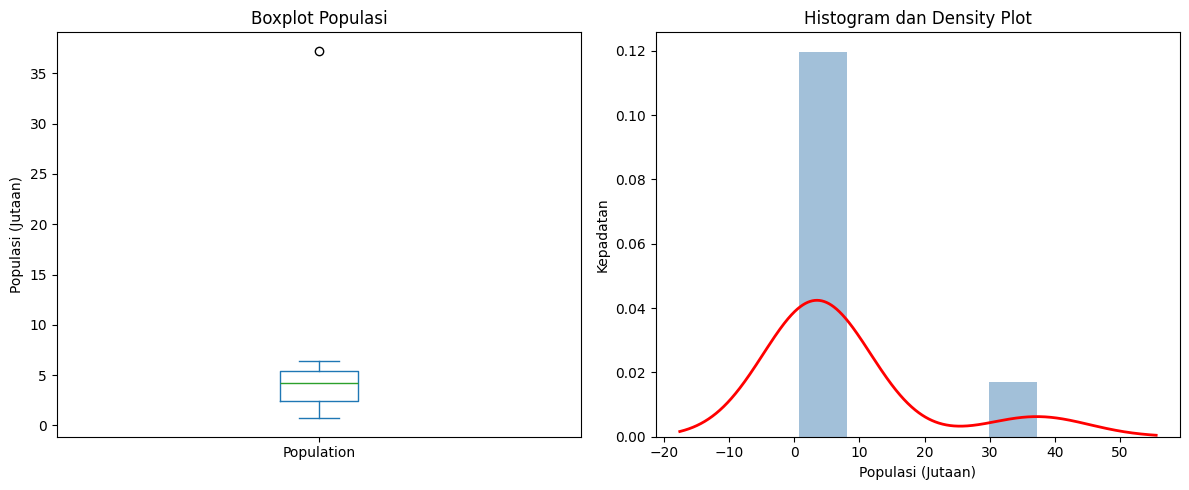

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
(state['Population'] / 1000000).plot.box(ax=axes[0])
axes[0].set_ylabel('Populasi (Jutaan)')
axes[0].set_title('Boxplot Populasi')

# Histogram dan Density
ax_hist = (state['Population'] / 1000000).plot.hist(ax=axes[1], density=True, bins=5, alpha=0.5, color='steelblue')
(state['Population'] / 1000000).plot.density(ax=axes[1], color='red', linewidth=2)
axes[1].set_xlabel('Populasi (Jutaan)')
axes[1].set_ylabel('Kepadatan')
axes[1].set_title('Histogram dan Density Plot')

plt.tight_layout()
plt.show()


***
## 4. Eksplorasi Data Biner dan Kategorikal

### Penjelasan Teori

Untuk data kategorikal, proporsi dan persentase sering kali cukup menceritakan karakteristik informasi.

* **Bar Chart:** Menggambarkan frekuensi setiap kategori dengan batang vertikal atau horizontal.
* **Mode:** Kategori yang paling sering muncul dalam data.
* **Expected Value:** Rerata nilai yang diharapkan berdasarkan probabilitas kemunculan suatu kategori.


Data Penyebab Keterlambatan Penerbangan:


,Count
Cause,
Carrier,64263
ATC,84045
Weather,11235
Security,343
Inbound,118427


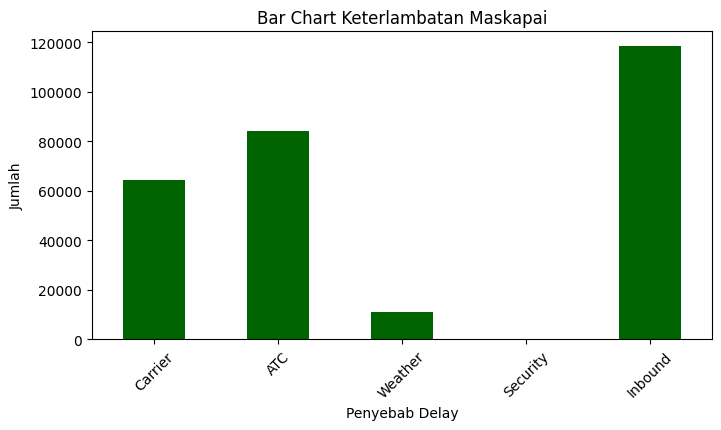

In [ ]:
dfw_data = {
    'Cause': ['Carrier', 'ATC', 'Weather', 'Security', 'Inbound'],
    'Count': [64263, 84045, 11235, 343, 118427]
}
dfw = pd.DataFrame(dfw_data).set_index('Cause')

print("Data Penyebab Keterlambatan Penerbangan:")
display(dfw)

ax = dfw.plot.bar(figsize=(8, 4), legend=False, color='darkgreen')
ax.set_xlabel('Penyebab Delay')
ax.set_ylabel('Jumlah')
plt.title('Bar Chart Keterlambatan Maskapai')
plt.xticks(rotation=45)
plt.show()


***
## 5. Korelasi

### Penjelasan Teori

Analisis korelasi melihat hubungan antar dua variabel numerik. Apakah nilai yang tinggi pada sebuah variabel diikuti nilai tinggi pada variabel lainnya?

* **Correlation Coefficient:** Mengukur sejauh mana dua variabel berasosiasi secara linear.
* **Scatterplot:** Visualisasi dasar untuk melihat korelasi antara dua variabel pada bidang koordinat.

Nilai korelasi bernilai antara negatif satu hingga positif satu. Nilai nol berarti tidak ada hubungan linear.


Matriks Korelasi:


,ATT,Verizon
ATT,1.000000,0.813799
Verizon,0.813799,1.000000


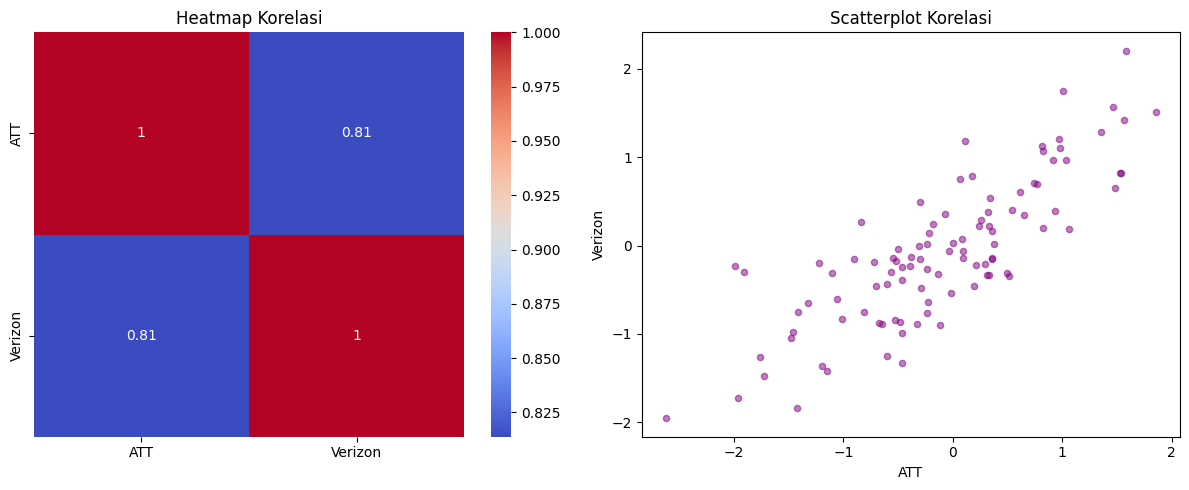

In [ ]:
np.random.seed(42)
T_vals = np.random.normal(loc=0, scale=1, size=100)
VZ_vals = np.add(np.multiply(T_vals, 0.8), np.random.normal(loc=0, scale=0.5, size=100))
telecom = pd.DataFrame({'ATT': T_vals, 'Verizon': VZ_vals})

print("Matriks Korelasi:")
display(telecom.corr())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(telecom.corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Heatmap Korelasi')

telecom.plot.scatter(x='ATT', y='Verizon', ax=axes[1], alpha=0.5, color='purple')
axes[1].set_xlabel('ATT')
axes[1].set_ylabel('Verizon')
axes[1].set_title('Scatterplot Korelasi')

plt.tight_layout()
plt.show()


***
## 6. Eksplorasi Dua atau Lebih Variabel

### Penjelasan Teori

Ketika kita memiliki sangat banyak data, scatterplot biasa bisa menjadi sangat padat sehingga polanya sulit terlihat.

* **Hexagonal Binning:** Mengelompokkan berbagai titik koordinat ke dalam bentuk segienam (hexagon) dan mewarnainya berdasarkan kepadatan.
* **Contour Plot:** Mirip peta topografi, menampilkan garis kontur kepadatan data.
* **Contingency Table:** Menampilkan jumlah sampel berdasarkan dua atau lebih variabel kategorikal (sering disebut pivot table).
* **Violin Plot:** Pengembangan dari boxplot yang menambahkan estimasi kepadatan di setiap sisi.


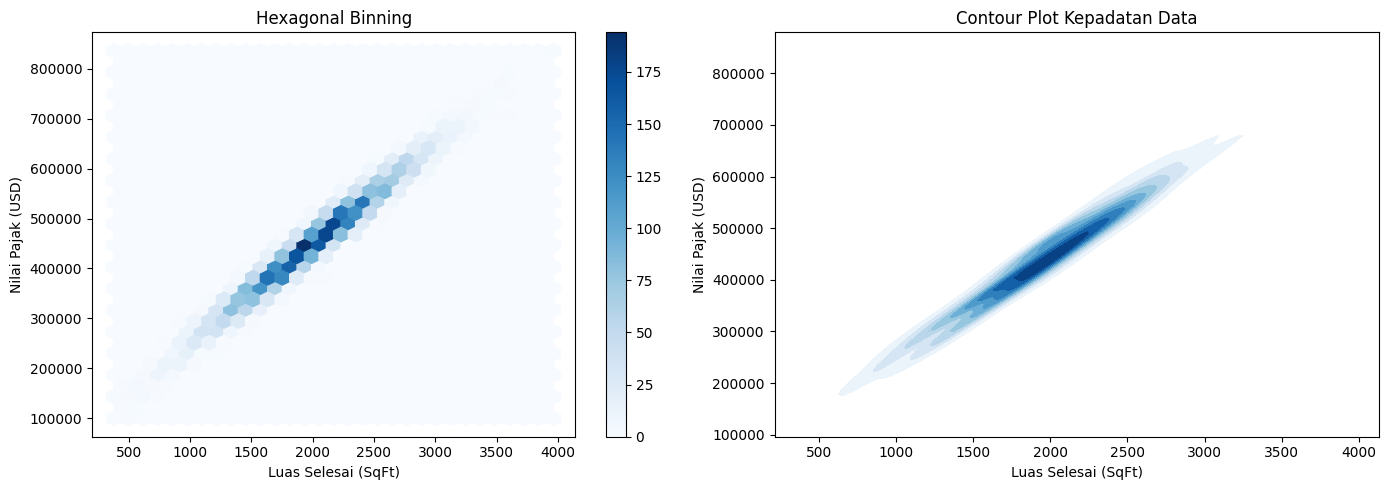

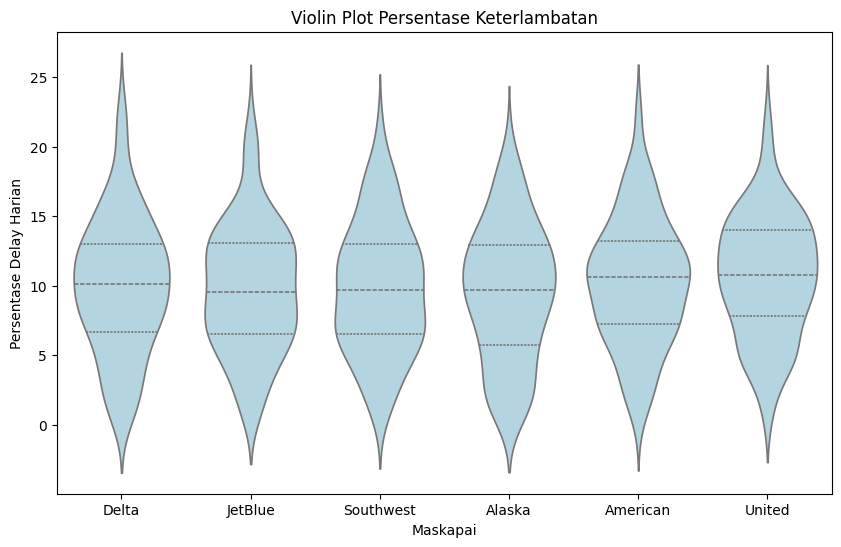

In [ ]:
np.random.seed(42)
sqft = np.abs(np.random.normal(loc=2000, scale=500, size=5000))
price = np.add(np.multiply(sqft, 200), np.random.normal(loc=50000, scale=20000, size=5000))

kc_tax0 = pd.DataFrame({
    'SqFtTotLiving': sqft,
    'TaxAssessedValue': price
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hexagonal Binning
kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue', gridsize=30, ax=axes[0], cmap='Blues')
axes[0].set_xlabel('Luas Selesai (SqFt)')
axes[0].set_ylabel('Nilai Pajak (USD)')
axes[0].set_title('Hexagonal Binning')

# Contour Plot
sns.kdeplot(x=kc_tax0['SqFtTotLiving'].sample(1000), y=kc_tax0['TaxAssessedValue'].sample(1000), ax=axes[1], cmap='Blues', fill=True)
axes[1].set_xlabel('Luas Selesai (SqFt)')
axes[1].set_ylabel('Nilai Pajak (USD)')
axes[1].set_title('Contour Plot Kepadatan Data')

plt.tight_layout()
plt.show()

# Violin Plot
airlines = ['Alaska', 'American', 'JetBlue', 'Delta', 'United', 'Southwest']
airline_col = np.random.choice(airlines, size=1000)
delays = np.abs(np.random.normal(loc=10, scale=5, size=1000))
airline_stats = pd.DataFrame({'airline': airline_col, 'pct_carrier_delay': delays})

plt.figure(figsize=(10, 6))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay', color='lightblue', inner='quartile')
plt.xlabel('Maskapai')
plt.ylabel('Persentase Delay Harian')
plt.title('Violin Plot Persentase Keterlambatan')
plt.show()
